# PoolPy Decoder - User-Friendly Interface

This notebook provides an easy-to-use interface for decoding readouts using the PoolPy decoder.

## Instructions:
1. **Cell 1**: Install dependencies from requirements.txt
2. **Cell 2**: Import required libraries
3. **Cell 3**: Define your decoder configuration (paths, parameters)
4. **Cell 4**: Run the decoder
5. **Cell 5**: View and download results

Simply fill in the configuration variables in Cell 3 and run the cells in order.

## Decoder types

The decoder auto infers the type of readout returns a type alongside the positive samples. This characteristic has four possible distinct values:

- **Continuous**: Used if the readout is inferred to be continuous and the single well value is inferred via penalized regression.
- **Unique**: Used if the readout is binary and there exists only one set of positive samples (of maximum *differentiate* samples) that can provide the measured readout.
- **Multiple**: Used if the readout is binary and there exists multiple sets of positive samples (of maximum *differentiate* samples) that can provide the measured readout.
- **Putative**: Used if the readout is binary and there exists more sets of positive samples (of maximum *differentiate* samples) that can provide the measured readout than the number of unique samples across all sets.


In [1]:
import subprocess
import sys
import os

# Setup environment from requirements.txt
print("Environment Setup")
print("=" * 70)

# Get the working directory
working_dir = os.getcwd()
print(f"Working directory: {working_dir}")
print()

requirements_path = os.path.join(working_dir, "requirements.txt")

# Try to read requirements.txt to show what packages are needed
try:
    with open(requirements_path, 'r') as f:
        requirements = [line.strip() for line in f if line.strip() and not line.startswith('#')]
    
    print(f"✓ Requirements file found: {requirements_path}")
    print(f"\nRequired packages ({len(requirements)} total):")
    for req in requirements:
        print(f"  - {req}")
    
    print("\n" + "-" * 70)
    print("Environment Status:")
    print(f"  Python version: {sys.version}")
    print(f"  Python executable: {sys.executable}")
    
    # Check if key packages are available
    key_packages = ['pandas', 'numpy', 'scipy', 'sklearn']
    for pkg_name in key_packages:
        try:
            __import__(pkg_name)
            print(f"  ✓ {pkg_name} is installed")
        except ImportError:
            print(f"  ✗ {pkg_name} is NOT installed")
    
except FileNotFoundError:
    print(f"✗ Requirements file not found: {requirements_path}")
    print("Please ensure requirements.txt exists in the working directory.")

print("=" * 70)
print("\nNote: For UV environments, dependencies are typically pre-installed.")
print("If you need to install packages, use: uv pip install -r requirements.txt")


Environment Setup
Working directory: /Users/ltalamanca/My Drive/Git/PoolPy

✓ Requirements file found: /Users/ltalamanca/My Drive/Git/PoolPy/requirements.txt

Required packages (50 total):
  - appnope==0.1.4
  - asttokens==3.0.0
  - cmcrameri==1.9
  - comm==0.2.2
  - contourpy==1.3.2
  - cycler==0.12.1
  - debugpy==1.8.14
  - decorator==5.2.1
  - et-xmlfile==2.0.0
  - executing==2.2.0
  - fonttools==4.57.0
  - ipykernel==6.29.5
  - ipython==9.2.0
  - ipython-pygments-lexers==1.1.1
  - jedi==0.19.2
  - jupyter-client==8.6.3
  - jupyter-core==5.7.2
  - kiwisolver==1.4.8
  - matplotlib==3.7.3
  - matplotlib-inline==0.1.7
  - nest-asyncio==1.6.0
  - numpy==1.26.4
  - openpyxl==3.1.5
  - packaging==25.0
  - pandas==2.2.3
  - parso==0.8.4
  - pexpect==4.9.0
  - pillow==11.2.1
  - platformdirs==4.3.7
  - prompt-toolkit==3.0.51
  - psutil==7.0.0
  - ptyprocess==0.7.0
  - pure-eval==0.2.3
  - pygments==2.19.1
  - pyparsing==3.2.3
  - python-dateutil==2.9.0.post0
  - pytz==2025.2
  - pyzmq==26.4

In [2]:
import pandas as pd
import numpy as np
import subprocess
import os
from pathlib import Path

print("✓ All libraries imported successfully!")
print(f"\nPython executable: {sys.executable}")
print(f"Working directory: {os.getcwd()}")


✓ All libraries imported successfully!

Python executable: /Users/ltalamanca/uv_2/bin/python
Working directory: /Users/ltalamanca/My Drive/Git/PoolPy


## Configuration

Edit the variables below to specify your decoder settings. By default, the notebook now uses the test folder in this workspace.

Parameters:
- path_to_WA: Path to the well assignment (WA) matrix CSV file (defaults to working_dir/test/test_wa_notebook.csv)
- readout: Path to the readout CSV file, binary or continuous (defaults to working_dir/test/test_continuous_notebook.csv)
- differentiate: Maximum number of expected active compounds (for sparsity control), default: 2
- diluting: Whether to use dilution scaling in continuous decoding (True/False), default: True
- min_signal: Optional minimum signal threshold (set to None to skip), default: None
- output_dir: Directory where decoded results will be saved (defaults to working_dir/test)
- python_executable: Python executable to use (automatically uses the current Python kernel)

To use custom paths:
Simply edit the lines in Cell 5, for example:
```python
path_to_WA = os.path.join(working_dir, "path/to/my_wa_matrix.csv")
readout = os.path.join(working_dir, "data/my_readout.csv")
```
The decoder auto-infers if the readout is binary or continous.

In [3]:
# ============================================================================
# USER CONFIGURATION - EDIT THESE VARIABLES
# ============================================================================

# Get the working directory (set automatically)
working_dir = os.getcwd()

# Default test folder containing decoder and sample files
test_dir = os.path.join(working_dir, "test")

# Path to the well assignment (WA) matrix CSV file
path_to_WA = os.path.join(test_dir, "test_wa_notebook.csv")

# Path to the readout CSV file (binary or continuous format)
readout = os.path.join(test_dir, "test_continuous_notebook.csv")

# Maximum number of expected postive samples
differentiate = 2

# Whether to use dilution scaling in continuous decoding (True/False)
diluting = True

# Optional minimum signal threshold (set to None to skip)
min_signal = None

# Continuous decoder hyperparameters (explicitly passed to decode_N.py)
# alpha: regularization strength (higher => stronger regularization)
alpha = 0.05
# l1_ratio: 1.0 = Lasso, 0.0 = Ridge, values in between = Elastic-Net style
l1_ratio = 1

# Output directory for results (defaults to test folder)
output_dir = test_dir

# Python executable (uses the current Python that's running the notebook)
python_executable = sys.executable

# ============================================================================
# Validation: Check if input files exist
# ============================================================================

print("Configuration:")
print("=" * 70)
print(f"Working Directory: {working_dir}")
print(f"Test Directory:    {test_dir}")
print(f"WA Matrix:         {os.path.basename(path_to_WA)}")
print(f"Readout CSV:       {os.path.basename(readout)}")
print(f"Differentiate:     {differentiate}")
print(f"Diluting:          {diluting}")
print(f"Min Signal:        {min_signal}")
print(f"Alpha:             {alpha}")
print(f"L1 Ratio:          {l1_ratio}")
print(f"Output Directory:  {output_dir}")
print(f"Python Executable: {python_executable}")
print("=" * 70)

# Check if files exist
print("\nValidation:")
if os.path.exists(path_to_WA):
    print(f"✓ WA Matrix file found: {os.path.basename(path_to_WA)}")
else:
    print(f"✗ WA Matrix file NOT found: {os.path.basename(path_to_WA)}")
    print(f"  Looking in: {path_to_WA}")

if os.path.exists(readout):
    print(f"✓ Readout file found: {os.path.basename(readout)}")
else:
    print(f"✗ Readout file NOT found: {os.path.basename(readout)}")
    print(f"  Looking in: {readout}")

if os.path.exists(output_dir):
    print(f"✓ Output directory exists: {output_dir}")
else:
    print(f"✗ Output directory does NOT exist: {output_dir}")

print(f"✓ Python executable: {python_executable}")

print("=" * 70)

Configuration:
Working Directory: /Users/ltalamanca/My Drive/Git/PoolPy
Test Directory:    /Users/ltalamanca/My Drive/Git/PoolPy/test
WA Matrix:         test_wa_notebook.csv
Readout CSV:       test_continuous_notebook.csv
Differentiate:     2
Diluting:          True
Min Signal:        None
Alpha:             0.05
L1 Ratio:          1
Output Directory:  /Users/ltalamanca/My Drive/Git/PoolPy/test
Python Executable: /Users/ltalamanca/uv_2/bin/python

Validation:
✓ WA Matrix file found: test_wa_notebook.csv
✓ Readout file found: test_continuous_notebook.csv
✓ Output directory exists: /Users/ltalamanca/My Drive/Git/PoolPy/test
✓ Python executable: /Users/ltalamanca/uv_2/bin/python


## Execute Decoder

Run the decoder with the configuration settings from the previous cell.

This interface explicitly passes continuous decoder hyperparameters:
- alpha (default 0.05)
- l1_ratio (default 1)

Change them in the configuration cell before running this step.

In [4]:
# Use configured Python executable, fallback to system Python
exec_python = python_executable if os.path.exists(python_executable) else sys.executable

# Path to decode_N.py script (kept in project root)
script_path = os.path.join(working_dir, "decode_N.py")

if not os.path.exists(script_path):
    print(f"Error: decode_N.py not found at {script_path}")
    print(f"Expected location: {working_dir}")
else:
    # Build the decoder command
    cmd = [
        exec_python,
        script_path,
        "--path_to_WA", path_to_WA,
        "--readout", readout,
        "--differentiate", str(differentiate),
        "--diluting", "True" if diluting else "False",
        "--alpha", str(alpha),
        "--l1_ratio", str(l1_ratio),
    ]
    
    # Add optional min_signal parameter if provided
    if min_signal is not None:
        cmd.extend(["--min_signal", str(min_signal)])
    
    # Display the command being executed
    print("Executing decoder...")
    print("=" * 70)
    print("Continuous decoder args passed to decode_N.py:")
    print(f"  --alpha {alpha}")
    print(f"  --l1_ratio {l1_ratio}")
    print(f"Command: {' '.join(cmd)}")
    print("=" * 70)
    print()
    
    # Run the decoder
    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            cwd=output_dir,
            timeout=300  # 5-minute timeout
        )
        
        print(f"Return code: {result.returncode}")
        print()
        
        if result.stdout:
            print("STDOUT:")
            print(result.stdout)
        
        if result.stderr:
            print("STDERR:")
            print(result.stderr)
        
        # Check for success
        if result.returncode == 0:
            print("\n" + "=" * 70)
            print("✓ DECODING COMPLETED SUCCESSFULLY")
            print("=" * 70)
        else:
            print("\n" + "=" * 70)
            print("✗ DECODING FAILED")
            print("=" * 70)
    
    except subprocess.TimeoutExpired:
        print("✗ Decoder execution timed out (5 minutes)")
    except Exception as e:
        print(f"✗ Error running decoder: {e}")

Executing decoder...
Continuous decoder args passed to decode_N.py:
  --alpha 0.05
  --l1_ratio 1
Command: /Users/ltalamanca/uv_2/bin/python /Users/ltalamanca/My Drive/Git/PoolPy/decode_N.py --path_to_WA /Users/ltalamanca/My Drive/Git/PoolPy/test/test_wa_notebook.csv --readout /Users/ltalamanca/My Drive/Git/PoolPy/test/test_continuous_notebook.csv --differentiate 2 --diluting True --alpha 0.05 --l1_ratio 1

Return code: 0


✓ DECODING COMPLETED SUCCESSFULLY


## View Results

Display and analyze the decoded results from the previous execution.


In [5]:
# Load and display the decoded results
output_csv = os.path.join(output_dir, "decoded_readouts.csv")

if os.path.exists(output_csv):
    print(f"Loading results from: {output_csv}")
    print("=" * 70)
    
    decoded_df = pd.read_csv(output_csv)
    
    print(f"\nDecoded Results (Total: {len(decoded_df)} readouts)")
    print("-" * 70)
    
    # Display the results in a formatted table
    pd.set_option('display.max_columns', None)
    pd.set_option('display.max_rows', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)
    
    print(decoded_df.to_string(index=False))
    
    print("\n" + "=" * 70)
    print(f"✓ Results file: {output_csv}")
    print("=" * 70)
    
    # Show summary statistics
    print("\nSummary:")
    print(f"  Total readouts: {len(decoded_df)}")
    print('You might need to scroll to the right to see all decoder results')
    if 'Decoded Type' in decoded_df.columns:
        print(f"\n  Decoded Types:")
        for dtype, count in decoded_df['Decoded Type'].value_counts().items():
            print(f"    - {dtype}: {count}")
    
else:
    print(f"✗ Results file not found: {output_csv}")
    print("The decoder may not have run successfully or the output path is incorrect.")


Loading results from: /Users/ltalamanca/My Drive/Git/PoolPy/test/decoded_readouts.csv

Decoded Results (Total: 8 readouts)
----------------------------------------------------------------------
           readout_id Decoded Type                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         Decoder Output
         continuous_1   cont

## Grid search

Grid search function of the continuous decoder

In [1]:
import os
import numpy as np
import pandas as pd

# Settings
n_points = 100
working_dir = globals().get("working_dir", os.getcwd())
test_dir = os.path.join(working_dir, "test")
os.makedirs(test_dir, exist_ok=True)

# Paths
pooling_path = os.path.join(test_dir, "3D_pooling.csv")          # samples x pools design matrix
readout_path = os.path.join(test_dir, "test_continuous_grid.csv")
original_tracks_path = os.path.join(test_dir, "test_original_tracks.csv")
pooled_tracks_path = os.path.join(test_dir, "test_pooled_tracks.csv")
truth_path = os.path.join(test_dir, "test_point_truth.csv")

rng = np.random.default_rng(20260709)

# 1) Load pooling matrix (expected shape: n_samples x n_pools = 1000 x 30)
pooling_df = pd.read_csv(pooling_path, index_col=0)
pooling_matrix = pooling_df.values
n_samples, n_pools = pooling_matrix.shape
sample_names = pooling_df.index.to_list()
pool_names = pooling_df.columns.to_list()

# 2) Generate one baseline 100-point track per sample
#    Result: 1000 samples x 100 points
time_axis = np.linspace(0, 1, n_points)
tracks = np.zeros((n_samples, n_points), dtype=float)

for i in range(n_samples):
    center = rng.uniform(0.2, 0.8)
    width = rng.uniform(0.05, 0.18)
    amplitude = rng.uniform(0.0, 0.5)
    base_track = amplitude * np.exp(-0.5 * ((time_axis - center) / width) ** 2)
    base_track += rng.uniform(0.0, 0.01, size=n_points)
    tracks[i] = base_track

# 3) At each point, with 90% probability boost exactly one sample strongly;
#    with 10% probability do nothing.
truth_rows = []
for point_idx in range(n_points):
    has_positive = rng.random() < 0.90
    if has_positive:
        pos_idx = int(rng.integers(0, n_samples))
        boost = float(rng.uniform(20.0, 45.0))
        tracks[pos_idx, point_idx] += boost
        truth_rows.append({
            "point": point_idx + 1,
            "has_increase": 1,
            "positive_sample": sample_names[pos_idx],
            "boost": boost,
        })
    else:
        truth_rows.append({
            "point": point_idx + 1,
            "has_increase": 0,
            "positive_sample": "",
            "boost": 0.0,
        })

# 4) Save the original per-sample tracks (1000 samples x 100 points)
track_cols = [f"point_{i+1}" for i in range(n_points)]
original_tracks_df = pd.DataFrame(tracks, index=sample_names, columns=track_cols)
original_tracks_df.to_csv(original_tracks_path)

# 5) Pool by summing tracks at each point using the provided samples x pools matrix
#    pooling_matrix.T has shape 30 x 1000, so result is 30 x 100
pooled_clean = pooling_matrix.T @ tracks

# 6) Add independent normal and lognormal noise to every pool and point
normal_noise = rng.normal(loc=0.0, scale=0.05, size=pooled_clean.shape)
lognormal_noise = rng.lognormal(mean=0.0, sigma=0.2, size=pooled_clean.shape)
pooled_noisy = pooled_clean + normal_noise + lognormal_noise

# 7) Save pooled tracks with rows = points and columns = pool readouts
pooled_tracks_df = pd.DataFrame(
    pooled_noisy.T,
    index=[f"point_{i+1}" for i in range(n_points)],
    columns=pool_names,
)
pooled_tracks_df.to_csv(pooled_tracks_path)

# 8) Also save readout file in payload format for downstream decoder code
readout_rows = []
for i, pool_name in enumerate(pool_names):
    payload = ",".join(f"{v:.5f}" for v in pooled_noisy[i])
    readout_rows.append({"readout_id": pool_name, "readout_payload": payload})
readout_df = pd.DataFrame(readout_rows)
readout_df.to_csv(readout_path, index=False)

# 9) Save per-point ground truth for the boost events
truth_df = pd.DataFrame(truth_rows)
truth_df.to_csv(truth_path, index=False)

n_positive_points = int(truth_df["has_increase"].sum())
n_zero_points = n_points - n_positive_points

print("Synthetic 3D pooling data generated using 3D_pooling.csv")
print(f"Pooling matrix:  {pooling_path} ({n_samples} samples x {n_pools} pools)")
print(f"Original tracks: {original_tracks_path} ({n_samples} samples x {n_points} points)")
print(f"Pooled tracks:   {pooled_tracks_path} ({n_points} points x {n_pools} pools)")
print(f"Readout file:    {readout_path} ({n_pools} pooled readouts)")
print(f"Truth table:     {truth_path} ({n_points} points)")
print(f"Boosted points:  {n_positive_points}")
print(f"Unchanged points:{n_zero_points}")


Synthetic 3D pooling data generated using 3D_pooling.csv
Pooling matrix:  /Users/ltalamanca/My Drive/Git/PoolPy/test/3D_pooling.csv (1000 samples x 30 pools)
Original tracks: /Users/ltalamanca/My Drive/Git/PoolPy/test/test_original_tracks.csv (1000 samples x 100 points)
Pooled tracks:   /Users/ltalamanca/My Drive/Git/PoolPy/test/test_pooled_tracks.csv (100 points x 30 pools)
Readout file:    /Users/ltalamanca/My Drive/Git/PoolPy/test/test_continuous_grid.csv (30 pooled readouts)
Truth table:     /Users/ltalamanca/My Drive/Git/PoolPy/test/test_point_truth.csv (100 points)
Boosted points:  88
Unchanged points:12


In [ ]:
# Check how often all channels are 0 in the readout
import os
import pandas as pd



# Reuse variables from setup cell when available
test_dir = os.path.join(os.getcwd(), "test")
script_path = os.path.join(os.getcwd(), "Decode_N.py")
readout_path = os.path.join(os.getcwd(), "test", "test_pooled_tracks.csv")


import subprocess

cmd = [
    "python",
    script_path,
    "--path_to_WA", pooling_path,
    "--readout", readout_path,
    "--differentiate", str(1),
    "--diluting", "False",
    "--force_continuous", "True",
    "--grid_search", "True" ,
    "--return_all_fits", "True",
    "--save_grid_decoders", "True",
    "--grid_objective", 'r2',
]

res = subprocess.run(
    cmd,
    cwd=test_dir,
    capture_output=True,
    text=True,
    check=False,
    timeout=60000,
 )

print("Exit code:", res.returncode)
if res.stdout:
    print("\nSTDOUT:\n" + res.stdout.strip())
if res.stderr:
    print("\nSTDERR:\n" + res.stderr.strip())

Truth tracks shape: samples=1000, points=100


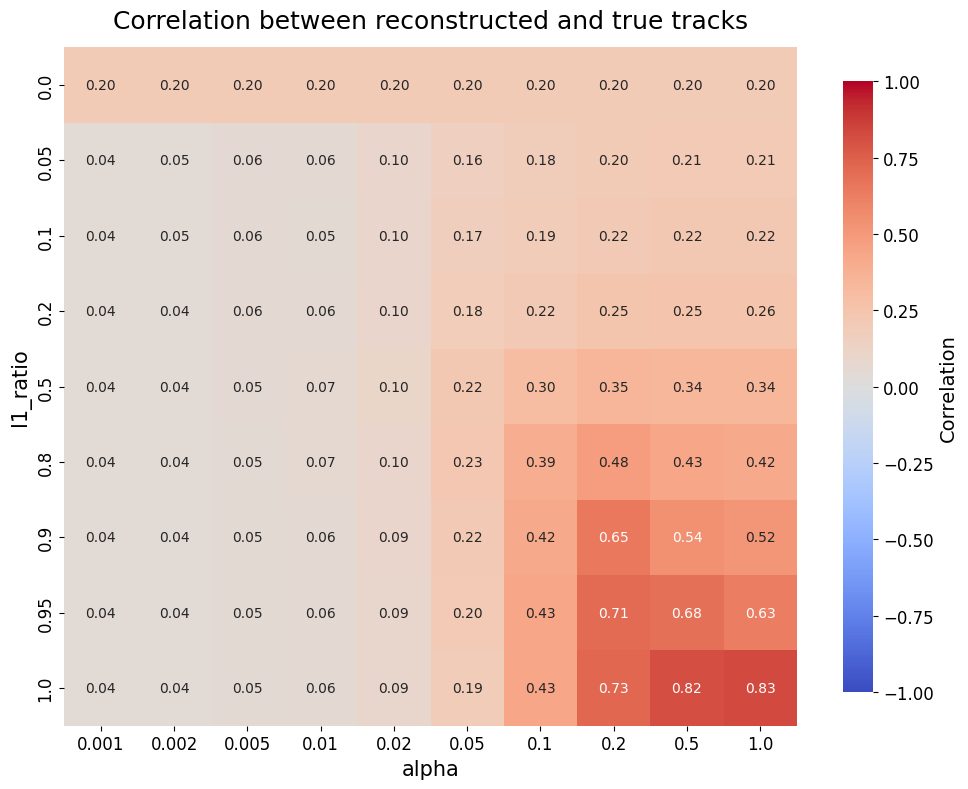

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# Settings
n_points = 100
working_dir = globals().get("working_dir", os.getcwd())
test_dir = os.path.join(working_dir, "test")
os.makedirs(test_dir, exist_ok=True)

# Paths
pooling_path = os.path.join(test_dir, "3D_pooling.csv")          # samples x pools design matrix
readout_path = os.path.join(test_dir, "test_continuous_grid.csv")
original_tracks_path = os.path.join(test_dir, "test_original_tracks.csv")
pooled_tracks_path = os.path.join(test_dir, "test_pooled_tracks.csv")
truth_path = os.path.join(test_dir, "test_point_truth.csv")

truth_path = os.path.join(test_dir, "test_original_tracks.csv")
decoded_path    = os.path.join(test_dir, "decoded_grid_decoders.csv")
# Load decoded grid-search results
decoded_df = pd.read_csv(decoded_path)

# Load truth tracks: first column is sample label, remaining columns are track values per point
truth_df = pd.read_csv(truth_path, header=None)

true_tracks = truth_df.iloc[1:, 1:].to_numpy()  # shape (n_samples, n_points)
true_tracks=true_tracks.astype(float)
n_samples, n_points = true_tracks.shape

print(f"Truth tracks shape: samples={n_samples}, points={n_points}")

# Concatenate true tracks across points and samples
# We want a vector ordered as: point 0, all samples; point 1, all samples; ... point 99, all samples.
true_flat = true_tracks.T.reshape(-1)

def parse_decoderoutput(payload):
    return np.array(ast.literal_eval(payload))

# Column names for alpha and l1_ratio in decoded file
if "alphascaled" in decoded_df.columns:
    alpha_col = "alphascaled"
elif "alpha" in decoded_df.columns:
    alpha_col = "alpha"
else:
    raise ValueError("No alpha/alphascaled column found in decoded_grid_decoders.csv")

if "alphal1ratio" in decoded_df.columns:
    l1_col = "alphal1ratio"
elif "l1_ratio" in decoded_df.columns:
    l1_col = "l1_ratio"
else:
    raise ValueError("No alphal1ratio/l1_ratio column found in decoded_grid_decoders.csv")

results = []

for (alpha, l1), group in decoded_df.groupby([alpha_col, l1_col]):
    # Parse decoderoutput for each point in this group
    recon_vectors = group["decoder_output"].apply(parse_decoderoutput).tolist()
    recon_matrix = np.vstack(recon_vectors)  # shape (n_points_group, n_samples_recon)

    # Sanity: expect 100 points in this group and same number of samples as truth
    if recon_matrix.shape[0] != n_points:
        print(f"Skipping alpha={alpha}, l1={l1}: expected {n_points} points, got {recon_matrix.shape[0]}")
        continue
    if recon_matrix.shape[1] != n_samples:
        print(f"Skipping alpha={alpha}, l1={l1}: expected {n_samples} samples, got {recon_matrix.shape[1]}")
        continue

    recon_flat = recon_matrix.reshape(-1)

    # Correlation between reconstructed and true
    corr = float(np.corrcoef(true_flat, recon_flat)[0, 1])
    results.append({"alpha": alpha, "l1_ratio": l1, "corr": corr})

res_df = pd.DataFrame(results)
res_df.to_csv("test/grid_search_track_correlations.csv", index=False)

# Heatmap pivot
heatmap_df = res_df.pivot(index="l1_ratio", columns="alpha", values="corr")

plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    cbar_kws={"shrink": 0.9}
)

ax.set_title("Correlation between reconstructed and true tracks", fontsize=18, pad=14)
ax.set_xlabel("alpha", fontsize=15)
ax.set_ylabel("l1_ratio", fontsize=15)
ax.tick_params(axis="both", labelsize=12)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)
cbar.set_label("Correlation", fontsize=14)
plt.tight_layout()

plt.savefig("test/grid_search_correlation_heatmap.png", dpi=300)
plt.show()

plt.close()

